In [1]:
import pandas as pd
from sdpm.experiments.util import summarize_experiments, metric_matrix_from_melt, check_results, ranks_from_results, metric_latex_table_from_melt, plot_cd_diagram_paper, RC_PARAMS, delete_duplicates
from sdpm.naming import get_model_name, get_metric_name
import scikit_posthocs as sp
import matplotlib.pyplot as plt

plt.rcParams.update(RC_PARAMS)

In [2]:
df = pd.read_csv("sdpm/experiments/results/final_results.csv", delimiter=';')
check_results(df, folds=4, repeats=10)

[OK] Model `deephit`, dataset `flchain` is ok
[OK] Model `deephit`, dataset `ovarian` is ok
[OK] Model `deephit`, dataset `pbc` is ok
[OK] Model `deephit`, dataset `retinopathy` is ok
[OK] Model `deephit`, dataset `rotterdam` is ok
[OK] Model `deephit`, dataset `seer` is ok
[OK] Model `deephit`, dataset `support` is ok
[OK] Model `deephit`, dataset `tcga_gbm` is ok
[OK] Model `deephit`, dataset `vlbw` is ok
[OK] Model `deephit`, dataset `whas500` is ok
[OK] Model `deepsurv`, dataset `flchain` is ok
[OK] Model `deepsurv`, dataset `ovarian` is ok
[OK] Model `deepsurv`, dataset `pbc` is ok
[OK] Model `deepsurv`, dataset `retinopathy` is ok
[OK] Model `deepsurv`, dataset `rotterdam` is ok
[OK] Model `deepsurv`, dataset `seer` is ok
[OK] Model `deepsurv`, dataset `support` is ok
[OK] Model `deepsurv`, dataset `tcga_gbm` is ok
[OK] Model `deepsurv`, dataset `vlbw` is ok
[OK] Model `deepsurv`, dataset `whas500` is ok
[OK] Model `gbm_km`, dataset `flchain` is ok
[OK] Model `gbm_km`, dataset `o

True

In [3]:
df_folds_sum = summarize_experiments(df, metric_cols=('c_index', 'ibs', 'auc'))
df_results = metric_matrix_from_melt(df_folds_sum, metric='c_index')
df_results

ds_name,flchain,ovarian,pbc,retinopathy,rotterdam,seer,support,tcga_gbm,vlbw,whas500
model_name,,,,,,,,,,
deephit,0.930242,0.632055,0.957017,0.600438,0.698709,0.727679,0.882538,0.874044,0.782272,0.754325
deepsurv,0.933507,0.629308,0.983123,0.616686,0.705358,0.711616,0.890056,0.851972,0.892956,0.758059
gbm_km,0.931086,0.617410,0.954571,0.621816,0.693004,0.712202,0.891586,0.880712,0.781776,0.751318
gbm_wb,0.907389,0.621438,0.955820,0.613546,0.701862,0.727074,0.893516,0.872562,0.690642,0.704032
rsf,0.934827,0.623623,0.962596,0.631762,0.707301,0.725127,0.857285,0.851457,0.877285,0.766947
sdpm_mlp,0.935740,0.624777,0.992586,0.620831,0.705007,0.728720,0.891531,0.882994,0.888317,0.760016


In [4]:
metric_matrix_from_melt(df_folds_sum, metric='ibs')

ds_name,flchain,ovarian,pbc,retinopathy,rotterdam,seer,support,tcga_gbm,vlbw,whas500
model_name,,,,,,,,,,
deephit,0.074377,0.145851,0.102830,0.203246,0.173085,0.082160,0.114739,0.087028,0.101665,0.183832
deepsurv,0.046392,0.148460,0.020524,0.190070,0.150047,0.080395,0.102795,0.071472,0.090469,0.158793
gbm_km,0.047575,0.161693,0.037070,0.193389,0.152772,0.081599,0.103557,0.057301,0.100154,0.183212
gbm_wb,0.072538,0.165883,0.084230,0.215753,0.156296,0.083571,0.136648,0.091535,0.140430,0.193104
rsf,0.046396,0.145187,0.052962,0.193220,0.147540,0.080501,0.108192,0.066650,0.087657,0.160311
sdpm_mlp,0.045624,0.166369,0.011429,0.195728,0.146177,0.079635,0.097528,0.052809,0.083815,0.161135


In [5]:
metric_matrix_from_melt(df_folds_sum, metric='auc')

ds_name,flchain,ovarian,pbc,retinopathy,rotterdam,seer,support,tcga_gbm,vlbw,whas500
model_name,,,,,,,,,,
deephit,0.946788,0.666016,0.976253,0.611057,0.749374,0.741903,0.944947,0.928634,0.867021,0.784481
deepsurv,0.950527,0.664607,0.993665,0.645486,0.744697,0.726468,0.947273,0.905992,0.879263,0.778010
gbm_km,0.937995,0.660954,0.957178,0.635846,0.732887,0.712500,0.948300,0.934578,0.853568,0.774532
gbm_wb,0.898840,0.645387,0.956510,0.642769,0.695208,0.717235,0.931689,0.870611,0.830427,0.740664
rsf,0.953256,0.664255,0.973313,0.654297,0.753622,0.737078,0.940246,0.929299,0.899825,0.802433
sdpm_mlp,0.953658,0.658827,0.997802,0.654910,0.755968,0.739836,0.951407,0.931392,0.891639,0.788442


In [6]:
for metric in ['c_index', 'ibs', 'auc']:
    latex_table = metric_latex_table_from_melt(df_folds_sum, metric=metric)
    with open(f'results_{metric}.tex', 'w') as file:
        file.write(latex_table)

In [7]:
df_for_ranks = df.copy()
df_for_ranks.loc[:, "model_name"] = df_for_ranks.loc[:, "model_name"].apply(get_model_name)

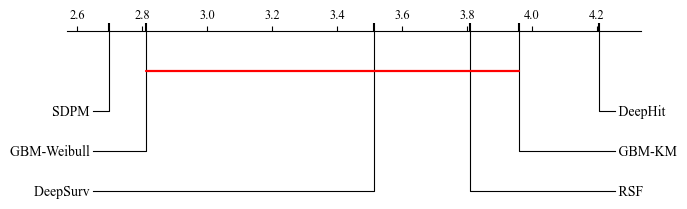

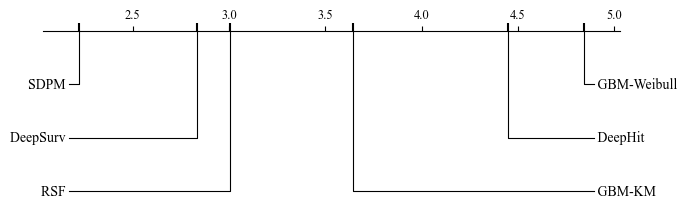

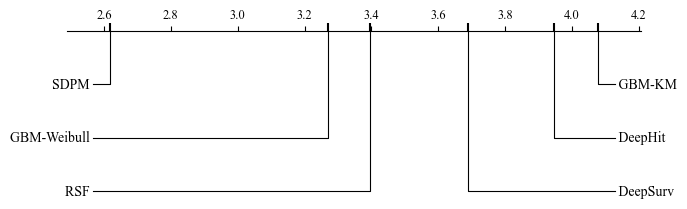

In [ ]:
ranks_df = ranks_from_results(df_for_ranks, models=df_for_ranks["model_name"].unique())
avg_ranks = ranks_df.drop(["ds_name", "fold_seed"], axis=1).groupby('model_name').mean()

stat_test_c_index = sp.posthoc_wilcoxon(df_for_ranks.sort_values(['ds_name', 'repeat_i', 'fold_i']), val_col="c_index", group_col="model_name", sort=True)
stat_test_ibs = sp.posthoc_wilcoxon(df_for_ranks.sort_values(['ds_name', 'repeat_i', 'fold_i']), val_col="ibs", group_col="model_name", sort=True)
stat_test_auc = sp.posthoc_wilcoxon(df_for_ranks.sort_values(['ds_name', 'repeat_i', 'fold_i']), val_col="auc", group_col="model_name", sort=True)

fig_c_index, ax_c_index = plot_cd_diagram_paper(avg_ranks["c_index_rank"], stat_test_c_index)
fig_ibs, ax_ibs = plot_cd_diagram_paper(avg_ranks["ibs_rank"], stat_test_ibs)
fig_auc, ax_auc = plot_cd_diagram_paper(avg_ranks["auc_rank"], stat_test_auc)
plt.show()